# **Univariable Linear Regression Model**

<div align="center">
    <img src=".\img\lin-reg-0.gif" width="25%">
    <img src=".\img\lin-reg-1.gif" width="25%">
    <img src=".\img\lin-reg-2.gif" width="25%">
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# CREATE DATA SET
size = 20
x = [i for i in range(size)]
y = [i + np.random.normal(0,0.9) for i in range(size)] 

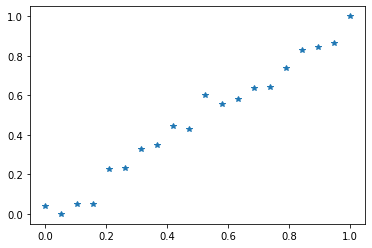

In [3]:
# NORMALIZE DATA
max_x = max(x)
min_x = min(x)
x = [(e - min_x)/(max_x - min_x) for e in x]

max_y = max(y)
min_y = min(y)
y = [(e - min_y)/(max_y - min_y) for e in y]

plt.plot(x,y,'*')
cx = []
cy = []

## **Hypothesis**
For 1 feature:

$$h(x_i) = x_i*w + b$$

Where: $h(x_i)$ is called "hypothesis"

In [4]:
def h(x,w,b):
  """Hypothesis function

  Args:
      x (float): i-th feature array sample
      w (float): slope of linear function
      b (float): bias

  Returns:
      float: model prediction
  """
  
  return x*w + b

## **Loss Function**

$$L(x_i) = Error = \frac{1}{2m}\sum_{i=0}^m (y_i - h(x_i)) ²$$

And $Error$ is MSE and represents the mean distance from points to prediction

$L(x_i)$ is commonly called "loss function"

In [5]:
def Error(y,x,w,b):
  """Loss function: Mean squared error 

  Args:
      y (list): expected output
      x (list): feature array
      w (float): slope
      b (float): bias

  Returns:
      float: result of MSE
  """

  m = len(x)
  err = 0
  for i in range(m):
    err = err + (y[i] - h(x[i], w, b))**2/(2*m)

  return err

## **Gradient Descent**
$$db = \frac{1}{m}\sum_{i=0}^m(y_i - h(x_i))(-1)$$

$$dw = \frac{1}{m}\sum_{i=0}^m(y_i - h(x_i))(-x_i)$$

<div align="center">
    <img src="./img/gradient-descent-0.png" width="50%">
</div>

In [6]:
def derivada(x,y,w,b):
  """Calculate derivative for gradient descent

  Args:
      x (list): 
      y (list): dependent variable
      w (float): slope
      b (float): bias

  Returns:
      tuple: derivative of bias and slope
  """

  m = len(x)

  db = sum([(y[i] - h(x[i],w,b))*-1 for i in range(m)])/(m*1.0)
  dw = sum([(y[i] - h(x[i],w,b))*-x[i] for i in range(m)])/(m*1.0)

  return db, dw

## **Change Parameter**

$$w_i = w_i - \alpha * \frac{\partial{\text{ Loss}}}{\partial{w_i}}$$

<div align="center">
    <img src=".\img\gradient-descent-1.png" width="25%">
</div>

In [7]:
def update(w,b,alfa,db,dw):
  """Change parameter function

  Args:
      w (float): slope
      b (float): bias
      alfa (float): parameter learning | learning rate
      db (float): partial derivative over b of MSE
      dw (float): partial derivative over w of MSE

  Returns:
      tuple: bias and slope adjusted
  """
  
  w = w - alfa*dw
  b = b - alfa*db
  return b,w  

In [8]:
def train(x,y,umbral,alfa):
  """Train function: Gradient Descent

  Args:
      x (list): input feature
      y (list): feature to predict
      umbral (float): treshold | avoid overfitting
      alfa (float): learning rate

  Returns:
      tuple: model variables
  """
  
  w = np.random.rand()
  b = np.random.rand()
  
  L = Error(x,y,w,b)
  
  while(L > umbral):
    # print(L)
    cx.append(w)
    cy.append(L)

    db, dw = derivada(x,y,w,b)
    b,w = update(w,b,alfa,db,dw) 
    L = Error(x,y,w,b) 
  
  return b,w

In [9]:
def test(x,y,b,w):
  plt.plot(x,y,'*')
  plt.plot(x,[h(xi,w,b) for xi in x])

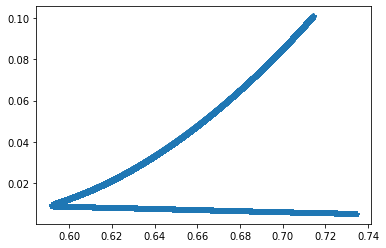

In [10]:
cx = []
cy = []
b, w = train(x,y,0.005,0.0001)
plt.plot(cx, cy, "*")

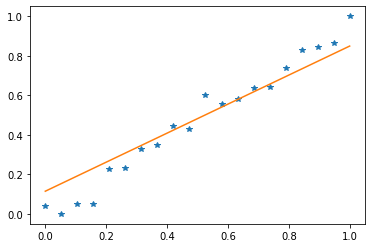

In [11]:
test(x,y,b,w)

### **REFERENCES**

[cnl.salk](https://cnl.salk.edu/~schraudo/teach/NNcourse/linear1.html)